Cleaned data saved to: data/cleaned\Cleaned_Citizen_Reviews.csv


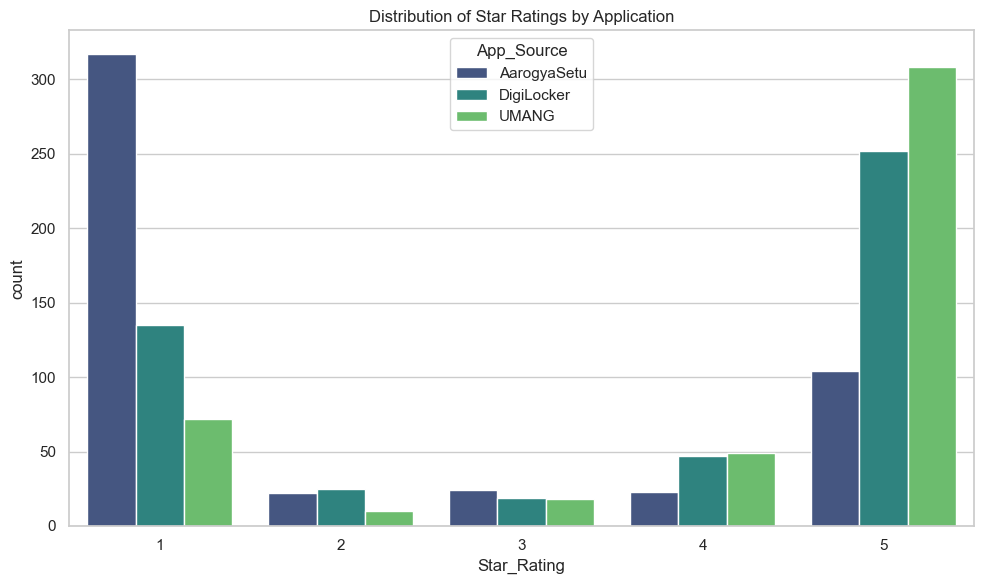

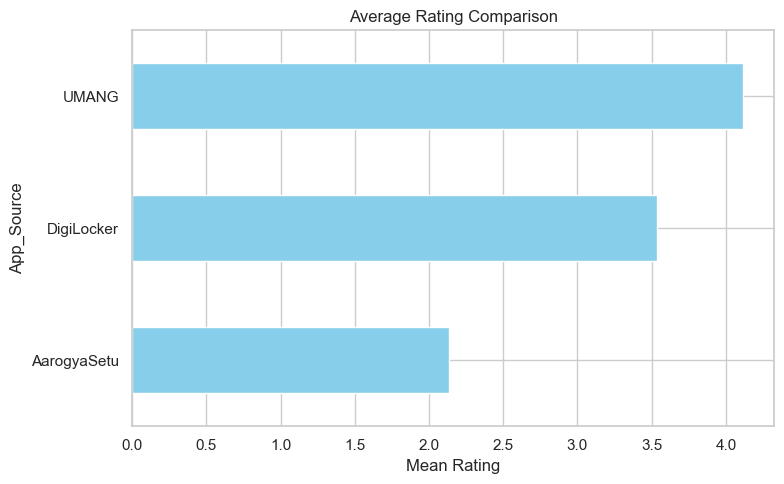

C:\Users\victo\AppData\Local\Temp\ipykernel_14892\291404047.py:81: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ts_data = app_df.set_index('Timestamp').resample('M').size()


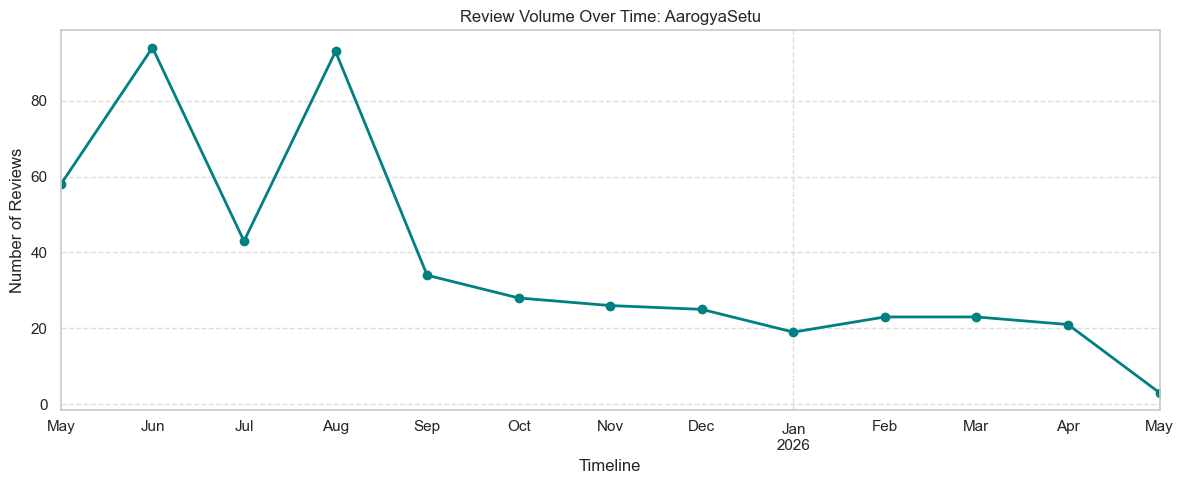

Generating Word Cloud for AarogyaSetu...


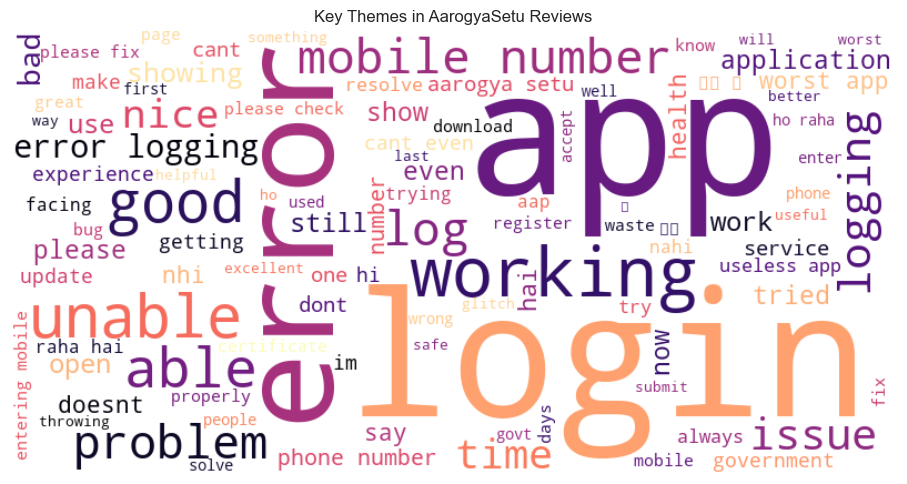

C:\Users\victo\AppData\Local\Temp\ipykernel_14892\291404047.py:81: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ts_data = app_df.set_index('Timestamp').resample('M').size()


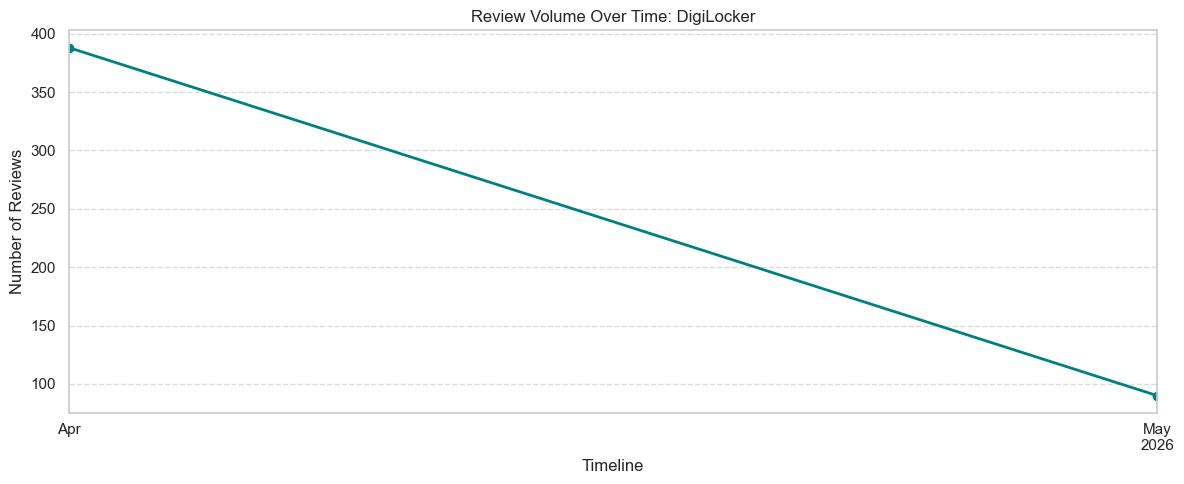

Generating Word Cloud for DigiLocker...


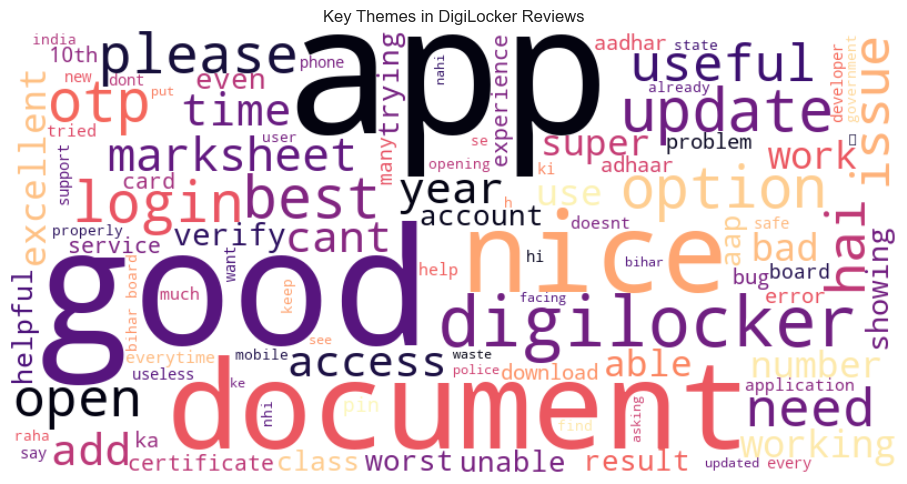

C:\Users\victo\AppData\Local\Temp\ipykernel_14892\291404047.py:81: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ts_data = app_df.set_index('Timestamp').resample('M').size()


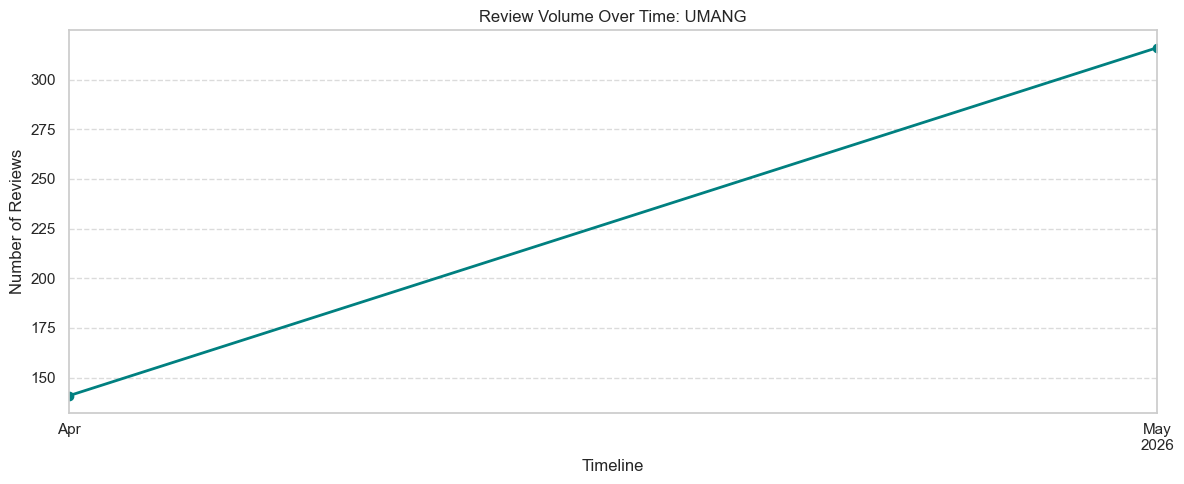

Generating Word Cloud for UMANG...


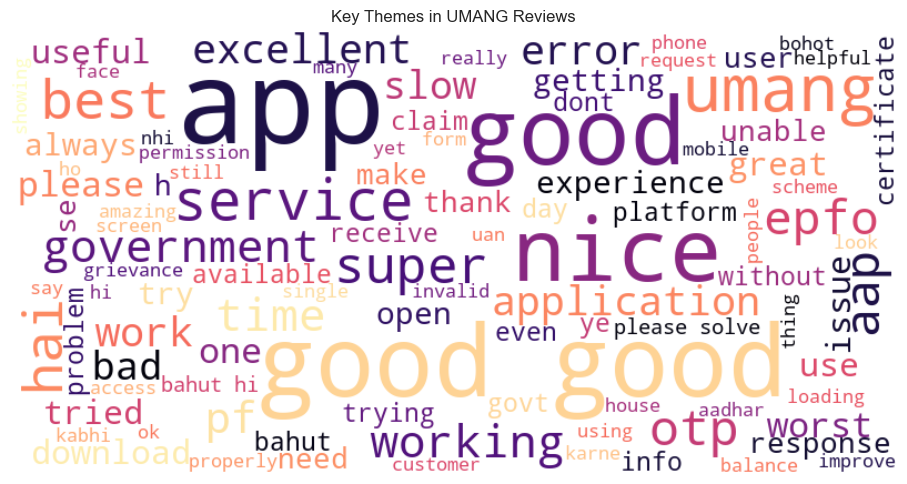

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import os
import re

# 1. Setup Directory Structure
folders = ['data/raw', 'data/cleaned', 'data/processed']
for folder in folders:
    os.makedirs(folder, exist_ok=True)

def run_pipeline():
    # 2. Load Raw Data
    raw_path = 'data/raw'
    raw_files = [f for f in os.listdir(raw_path) if f.endswith('.csv')]
    
    if not raw_files:
        print(f"No CSV files found in {raw_path}. Please check your folder.")
        return None

    all_data = []
    for file in raw_files:
        file_path = os.path.join(raw_path, file)
        temp_df = pd.read_csv(file_path)
        # Extract app name from filename for tracking
        temp_df['App_Source'] = file.split('_')[0] 
        all_data.append(temp_df)

    df = pd.concat(all_data, ignore_index=True)

    # 3. Data Cleaning
    df = df.drop_duplicates(subset=['Review_Text', 'Timestamp'])
    df = df.dropna(subset=['Review_Text', 'Star_Rating'])
    
    # Text Normalization
    df['Cleaned_Review'] = df['Review_Text'].astype(str).str.lower()
    df['Cleaned_Review'] = df['Cleaned_Review'].apply(lambda x: re.sub(r'[^\w\s]', '', x))
    
    # Noise Reduction
    df['Cleaned_Review'] = df['Cleaned_Review'].str.strip()
    df = df[df['Cleaned_Review'].str.len() > 2]
    
    # Standardize Timestamps
    df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
    df = df.dropna(subset=['Timestamp'])

    # 4. Save to data/cleaned
    cleaned_output = os.path.join('data/cleaned', 'Cleaned_Citizen_Reviews.csv')
    df.to_csv(cleaned_output, index=False)
    print(f"Cleaned data saved to: {cleaned_output}")

    # 5. Exploratory Data Analysis (EDA)
    sns.set_theme(style="whitegrid")
    
    # Visualization 1: Rating Counts by App (Aggregated)
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x='Star_Rating', hue='App_Source', palette='viridis')
    plt.title('Distribution of Star Ratings by Application')
    plt.tight_layout()
    plt.show()

    # Visualization 2: Average Rating per App (Aggregated)
    plt.figure(figsize=(8, 5))
    avg_ratings = df.groupby('App_Source')['Star_Rating'].mean().sort_values()
    avg_ratings.plot(kind='barh', color='skyblue')
    plt.title('Average Rating Comparison')
    plt.xlabel('Mean Rating')
    plt.tight_layout()
    plt.show()

    # --- NEW INDIVIDUAL APP ANALYSES ---
    apps = df['App_Source'].unique()
    
    for app in apps:
        app_df = df[df['App_Source'] == app]
        
        # Individual Review Volume Over Time
        plt.figure(figsize=(12, 5))
        # Resample to monthly volume (M) for clearer trends
        ts_data = app_df.set_index('Timestamp').resample('M').size()
        ts_data.plot(kind='line', marker='o', color='teal', linewidth=2)
        plt.title(f'Review Volume Over Time: {app}')
        plt.ylabel('Number of Reviews')
        plt.xlabel('Timeline')
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
        
        # Individual Word Cloud (Key Themes)
        print(f"Generating Word Cloud for {app}...")
        text_data = " ".join(app_df['Cleaned_Review'].dropna())
        
        if text_data.strip():
            wordcloud = WordCloud(width=800, height=400, 
                                  background_color='white', 
                                  colormap='magma', 
                                  max_words=100).generate(text_data)
            
            plt.figure(figsize=(10, 5))
            plt.imshow(wordcloud, interpolation='bilinear')
            plt.axis('off')
            plt.title(f'Key Themes in {app} Reviews')
            plt.tight_layout()
            plt.show()

    return df

# Run the full process
final_df = run_pipeline()

Starting Sentiment Analysis...
Deep analysis complete. File saved to: data/processed\Final_Analytic_Dataset.csv


C:\Users\victo\AppData\Local\Temp\ipykernel_14892\1671569415.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Star_Rating', y='Sentiment_Score', palette='coolwarm')


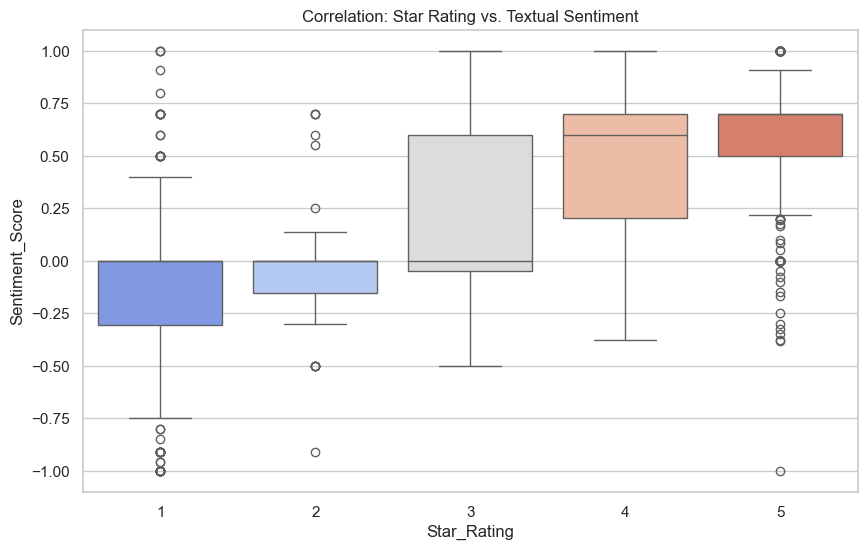

In [2]:
from textblob import TextBlob

def run_advanced_analysis(df):
    print("Starting Sentiment Analysis...")
    
    # 1. Calculate Sentiment Polarity
    df['Sentiment_Score'] = df['Cleaned_Review'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
    
    # 2. Categorize the scores
    df['Sentiment_Label'] = df['Sentiment_Score'].apply(
        lambda x: 'Positive' if x > 0.1 else ('Negative' if x < -0.1 else 'Neutral')
    )
    
    # 3. Feature Engineering: Review Length
    df['Review_Length'] = df['Cleaned_Review'].str.len()
    
    # 4. Save the Final Processed Dataset
    processed_path = os.path.join('data/processed', 'Final_Analytic_Dataset.csv')
    df.to_csv(processed_path, index=False)
    print(f"Deep analysis complete. File saved to: {processed_path}")
    
    # 5. Visualization: Sentiment vs Star Rating
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x='Star_Rating', y='Sentiment_Score', palette='coolwarm')
    plt.title('Correlation: Star Rating vs. Textual Sentiment')
    plt.show()
    
    return df

# To execute, simply call it using your previous final_df
final_df = run_advanced_analysis(final_df)